# House Price Prediction using Linear Regression

## Objective

The objective of this project is to build a Linear Regression model that predicts house prices using features such as area, bedrooms, bathrooms, floors, location, garage, and house condition.

## Dataset

This dataset contains information about different houses such as area, number of bedrooms, bathrooms, location, garage, condition, and price.

The target variable is **Price**.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [2]:
import pandas as pd

house = pd.read_csv("House Price Prediction Dataset2.csv")

### EDA (Exploratory Data Analysis)

In [5]:
house.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


### Observation

it is code show the 5 first row

The dataset contains information about houses.

Each row represents one house.

The target variable is Price.

In [8]:
house.shape

(2000, 10)


### Observation

The dataset contains 2000 rows and 10 columns.

In [10]:
house.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [16]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


### Observation

The dataset contains both numerical and categorical features.

The Price column is the target variable.

#### Null Check

In [21]:
house.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

### Observation

No missing values were found in the dataset.

In [30]:
house.duplicated().sum()

0

No duplicated values were found in the dataset.

In [34]:
house.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


### Observation

The descriptive statistics provide the average, minimum, maximum, and spread of numerical variables.

This helps us understand the overall characteristics of the dataset.

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


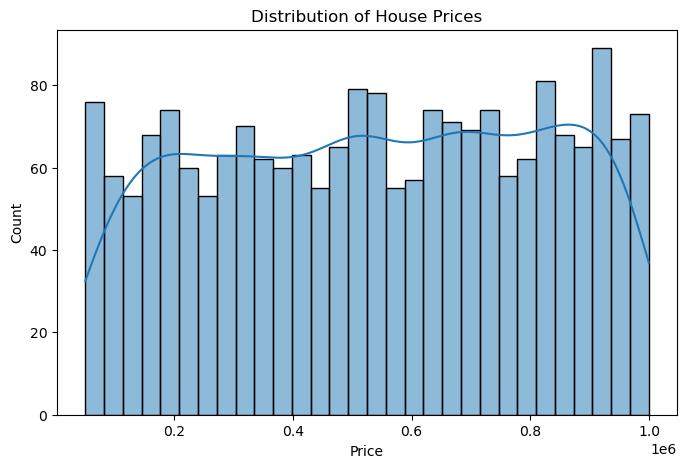

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(house["Price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

## Feature Selection

Feature selection means choosing the most useful variables that help predict the target variable (Price).

Selected Features:

- Area
- Bedrooms
- Bathrooms
- Floors
- YearBuilt
- Location
- Condition
- Garage

These features are selected because they are expected to influence house prices.

The **Id** column is not selected because it is only a unique identifier and does not affect the house price.

The **Price** column is the target variable that the model will predict.

In [54]:
# Select input features (X)
X = house[['Area',
           'Bedrooms',
           'Bathrooms',
           'Floors',
           'YearBuilt',
           'Location',
           'Condition',
           'Garage']]

# Select target variable (y)
y = house['Price']

In [56]:
X.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,1360,5,4,3,1970,Downtown,Excellent,No
1,4272,5,4,3,1958,Downtown,Excellent,No
2,3592,2,2,3,1938,Downtown,Good,No
3,966,4,2,2,1902,Suburban,Fair,Yes
4,4926,1,4,2,1975,Downtown,Fair,Yes


## Feature Selection

The following features were selected to predict house prices:

- Area
- Bedrooms
- Bathrooms
- Floors
- YearBuilt
- Location
- Condition
- Garage

These features are likely to influence house prices.

The **Id** column was not selected because it is only a unique identifier and does not affect the price.

The **Price** column is the target variable that the model will predict.

In [59]:
house.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

The dataset was checked for missing values using `isnull().sum()`

In [62]:
#: Check Categorical Columns
house.select_dtypes(include="object").columns

Index(['Location', 'Condition', 'Garage'], dtype='object')

In [64]:
house = pd.get_dummies(
    house,
    columns=["Location", "Condition", "Garage"],
    drop_first=True
)

In [66]:
house.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


## One-Hot Encoding

The categorical columns (Location, Condition, and Garage) were converted into numerical format using One-Hot Encoding.

This step is necessary because machine learning models cannot directly process text values.

After encoding, each category is represented by binary values (0 or 1).

#### Correlation Heatmap

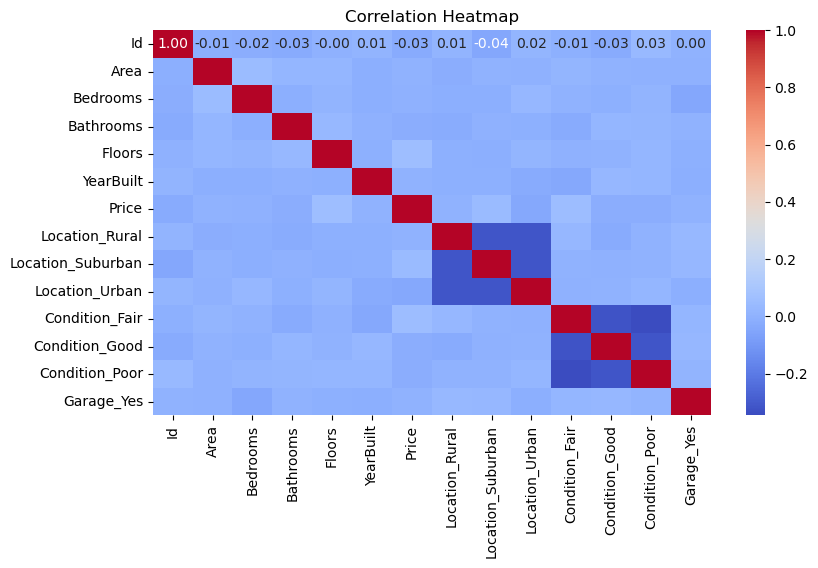

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Matrix
corr = house.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(9,5))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

Observation

- The heatmap shows how all columns are related to each other.

- Red colour means two columns are positively related.

- Blue colour means two columns are negatively related.
  
- Light colour means there is very little relationship.

- The diagonal values are 1.00 because every column is compared with itself.

- Most values are close to 0, so most features have a weak relationship.

- This means the dataset is suitable for training a Linear Regression model

#### Train/Test Split (80/20)

from sklearn.model_selection import train_test_split

# Input Features
X = house.drop("Price", axis=1)

# Target Variable
y = house["Price"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [110]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (1600, 13)
Testing Data : (400, 13)


### Observation

The dataset was successfully divided into training and testing sets.

- Training Data contains **1600 rows** and **13 features**.
- Testing Data contains **400 rows** and **13 features**.
- The model will learn from the training data and its performance will be evaluated using the testing data.
- An 80:20 split helps evaluate the model on unseen data and reduces the risk of overfitting.

. What is Train/Test Split?


Train/Test Split is a process of dividing the dataset into two parts. The training data is used to train the machine learning model, and the testing data is used to evaluate how well the model predicts on new, unseen data.

In [102]:
house.corr(numeric_only=True)["Price"].sort_values(ascending=False)

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Id                  -0.025643
Location_Urban      -0.038312
Name: Price, dtype: float64

Area has the highest positive correlation with Price. This means larger houses generally have higher prices. Other features like Bathrooms and Bedrooms also have a positive relationship with house prices.

In [104]:
house.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [106]:
## lowest Correlation with Price
house.corr(numeric_only=True)["Price"].sort_values().head(5)

Location_Urban   -0.038312
Id               -0.025643
Condition_Poor   -0.018437
Condition_Good   -0.017179
Bathrooms        -0.015737
Name: Price, dtype: float64

In [108]:
corr = house.corr(numeric_only=True)["Price"].sort_values(ascending=False)
# highest correlation with price 

print("Highest Correlation:")
print(corr.iloc[1])
print("Feature:", corr.index[1])

Highest Correlation:
0.055890259689214045
Feature: Floors


### Linear Regression 

In [118]:
from sklearn.linear_model import LinearRegression

# Create Model
lr_model = LinearRegression()

# Train Model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Observation

The Linear Regression model was successfully trained using the training dataset. The model has learned the relationship between the input features and house prices.

### Predict House Prices

In [122]:
# Predict House Prices

y_pred = lr_model.predict(X_test)

print(y_pred[:10])

[511317.73109931 557359.55652936 482838.34523391 540695.6411198
 549288.50244107 518144.16928401 523405.40235976 568346.51627797
 556990.3977267  573402.71846042]


These are the predicted house prices generated by the Linear Regression model for the first 10 houses in the testing dataset.

In [ ]:
# Evaluate Model
# Question

# Evaluate model using:

# Mean Squared Error (MSE)
# Root Mean Squared Error (RMSE)
# R² Score

In [125]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Squared Error (MSE): 78279764120.86243
Root Mean Squared Error (RMSE): 279785.21069002635
R2 Score: -0.006181784611834162


### Observation

The Linear Regression model was evaluated using MSE, RMSE, and R² Score.

The Mean Squared Error (MSE) is very high, which means the prediction errors are large.

The Root Mean Squared Error (RMSE) is also high, showing that the predicted house prices are far from the actual prices.

The R² Score is approximately -0.005, which means the model is not able to explain the relationship between the features and the house prices.

Overall, the Linear Regression model is not performing well on this dataset.

#### Scatter Plot

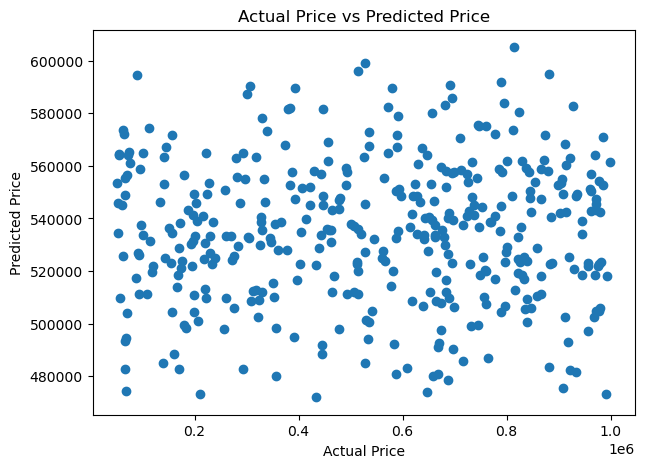

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual Price vs Predicted Price")

plt.show()

### Graph Analysis

The scatter plot shows that the predicted house prices are not close to the actual prices.

Most data points are scattered randomly instead of forming a diagonal line.

This means the Linear Regression model is unable to predict house prices accurately.

The model performance can be improved by adding better features or using a more advanced regression model.

#### Residual Plot

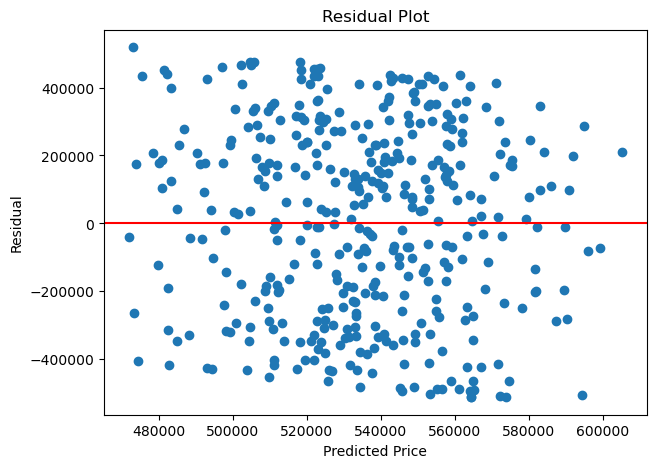

In [131]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

What is a Residual Plot?

A residual plot shows the difference between the actual house price and the predicted house price.

### Graph Analysis

The residual plot shows that the prediction errors are widely spread around the zero line.

Many residuals are far from zero, indicating large prediction errors.

Although there is no clear systematic pattern, the large spread suggests that the Linear Regression model is not performing well on this dataset.

A better regression model or additional features may improve the prediction accuracy.

#### Coefficient Analysis

In [134]:
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
9,Condition_Fair,24049.504733
4,Floors,23582.408499
7,Location_Suburban,11110.139855
11,Condition_Poor,4389.783506
12,Garage_Yes,2218.649484
6,Location_Rural,1826.466887
5,YearBuilt,116.775334
2,Bedrooms,53.249124
1,Area,-0.484192
0,Id,-12.007473


Ye table batata hai ki Linear Regression model ke hisaab se kis feature ka House Price par kitna effect hai.

Condition_Fair (24049) → Sabse zyada positive effect. Is feature se model ke hisaab se price badhta hai.

Floors (23582) → Jitne zyada floors, utna price badhne ka trend.

Location_Suburban → Suburban area me house hone se price badhne ka indication.

Garage_Yes → Garage hone se thoda positive effect.

YearBuilt → Naye ghar ka price thoda zyada ho sakta hai.

Negative values:

Condition_Good, Location_Urban, aur Bathrooms ke coefficients negative aaye hain. Is dataset aur model ke hisaab se ye features price ko kam predict kar rahe hain.



#### Bonus

In [137]:
from sklearn.linear_model import Ridge

In [141]:
ridge_model = Ridge(alpha=1.0)

In [143]:
ridge_model.fit(X_train, y_train)

Ridge()

This code trains the Ridge Regression model using the training dataset. The model learns the relationship between the input features and the house price.

In [145]:
ridge_pred = ridge_model.predict(X_test)

In [147]:
# Evaluate Ridge Model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE :", ridge_mse)
print("Ridge RMSE :", ridge_rmse)
print("Ridge R2 Score :", ridge_r2)


Ridge MSE : 78279532573.56367
Ridge RMSE : 279784.7968949773
Ridge R2 Score : -0.006178808380660206


Both Linear Regression and Ridge Regression produced similar results.

The Ridge Regression model has a slightly lower RMSE, but the improvement is very small.

Since both models have negative R² scores, neither model fits the data well.

A better dataset or additional useful features may improve prediction accuracy.

#### Compare Both Models

In [150]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE": [rmse, ridge_rmse],
    "R2 Score": [r2, ridge_r2]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,279785.210690,-0.006182
1,Ridge Regression,279784.796895,-0.006179


The comparison shows that Ridge Regression performed slightly better than Linear Regression because it has a slightly lower RMSE value.

However, the improvement is very small, and both models have negative R² scores.

This means the dataset does not have a strong relationship between the features and the target variable, so the models cannot accurately predict house prices.

More useful features and better-quality data may improve the model performance.

RMSE ➜ Jitna kam hoga, utna model better hoga.

R² Score ➜ Jitna 1 ke paas hoga, utna model better hoga. Negative value ka matlab model achha perform nahi kar raha.